In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import re 
import string

In [4]:
%pip install wordcloud


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (50000, 2)
Number of Rows: 50000
Number of Columns: 2


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [8]:
print(df["sentiment"].value_counts())

print("\nPercentage Distribution:")

print(df["sentiment"].value_counts(normalize=True) * 100)

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Percentage Distribution:
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


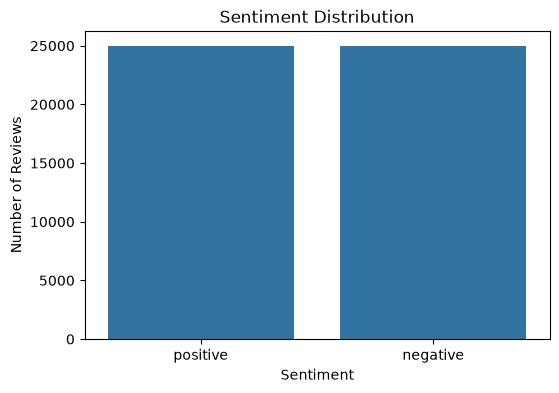

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [10]:
#Check Missing Values
print("Missing Values:")

print(df.isnull().sum())

Missing Values:
review       0
sentiment    0
dtype: int64


In [11]:
#Check Duplicate Reviews
print("Duplicate Rows:", df.duplicated().sum())

print(
    "Duplicate Reviews:",
    df["review"].duplicated().sum()
)

Duplicate Rows: 418
Duplicate Reviews: 418


In [12]:
#Create Review Length Columns
df["char_count"] = df["review"].astype(str).apply(len)

df["word_count"] = df["review"].astype(str).apply(
    lambda x: len(x.split())
)

df[["review", "sentiment", "char_count", "word_count"]].head()

,review,sentiment,char_count,word_count
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230


In [13]:
#Review Length Statistics
print("Character Count Statistics:")
print(df["char_count"].describe())

print("\nWord Count Statistics:")
print(df["word_count"].describe())

print("\nAverage Review Length by Sentiment:")

print(
    df.groupby("sentiment")["word_count"].mean()
)

Character Count Statistics:
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: char_count, dtype: float64

Word Count Statistics:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64

Average Review Length by Sentiment:
sentiment
negative    229.46456
positive    232.84932
Name: word_count, dtype: float64


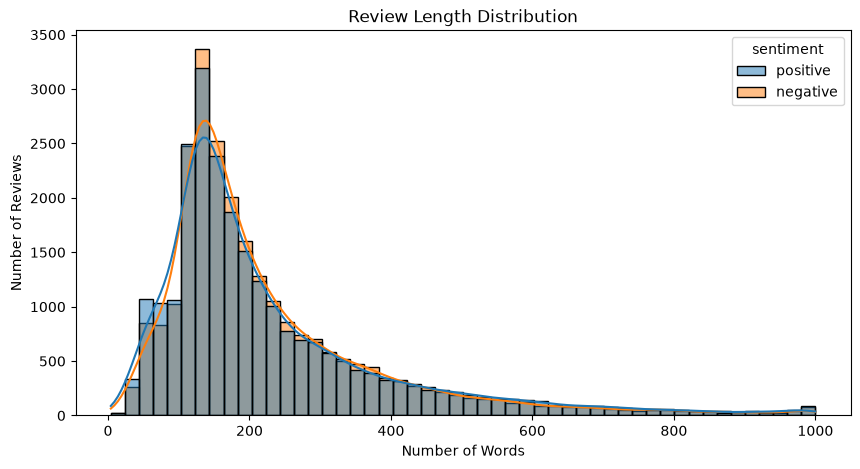

In [14]:
#Review Length Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df[df["word_count"] <= 1000],
    x="word_count",
    hue="sentiment",
    bins=50,
    kde=True
)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

In [15]:
#Basic Text Cleaning and Word Frequency
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"<.*?>", " ", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\d+", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_review"] = df["review"].apply(clean_text)

all_text = " ".join(df["clean_review"])

words = all_text.split()

word_counts = Counter(words)

top_words = word_counts.most_common(20)

word_frequency_df = pd.DataFrame(
    top_words,
    columns=["Word", "Frequency"]
)

word_frequency_df

,Word,Frequency
0,the,663999
1,and,320757
2,a,320617
3,of,288491
4,to,266938
5,is,210526
6,in,185073
7,it,154927
8,i,152158
9,this,149913


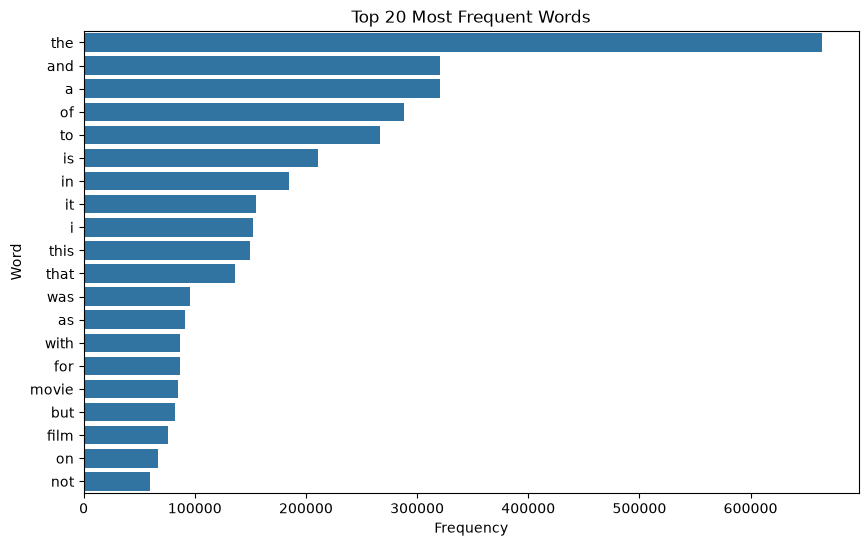

In [16]:
#Top 20 Most Frequent Words Graph
plt.figure(figsize=(10, 6))

sns.barplot(
    data=word_frequency_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Frequent Words")

plt.xlabel("Frequency")

plt.ylabel("Word")

plt.show()

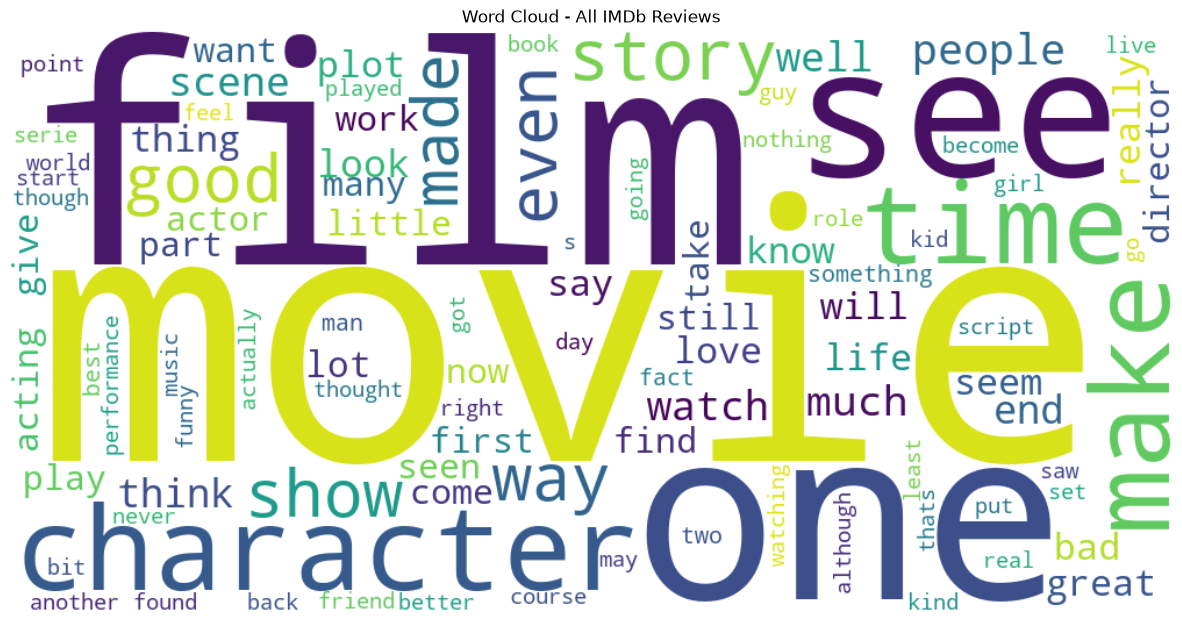

In [17]:
#Word Clouds
all_reviews = " ".join(df["clean_review"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(all_reviews)

plt.figure(figsize=(15, 8))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Word Cloud - All IMDb Reviews")

plt.show()